# Pandas Serialization Format Comparison

Benchmarking **read time**, **write time**, and **file size** across:
`CSV` · `CSV (gzip)` · `Parquet` · `Pickle` · `SQLite`

Plus a bonus section on how **a non-contiguous index** can silently bloat your Parquet files.

In [1]:
import sqlite3
import tempfile
import time
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

## Data Loading

Toggle `USE_REMOTE` to switch between local files and remote URLs.

In [2]:
USE_REMOTE = False

SOURCES = {
    'details': {
        'local': '/mnt/data/synced/data/standalone/ingatlan/ingatlan-details.parquet',
        'remote': 'https://share.borza.cc/ingatlan-details.parquet',
    },
    'listings': {
        'local': '/mnt/data/synced/data/standalone/ingatlan/ingatlan-listings.parquet',
        'remote': 'https://share.borza.cc/ingatlan-listings.parquet',
    },
}

SAMPLE_SIZE_DETAILS = 50_000
SAMPLE_SIZE_LISTINGS = 50_000


def load_dataset(name: str, use_remote: bool = USE_REMOTE) -> pd.DataFrame:
    return pd.read_parquet(SOURCES[name]['remote' if use_remote else 'local'])


details_sample = load_dataset('details').sample(SAMPLE_SIZE_DETAILS, random_state=42)
listings_sample = load_dataset('listings').sample(SAMPLE_SIZE_LISTINGS, random_state=42)

print(f'details sample:  {details_sample.shape}')
print(f'listings sample: {listings_sample.shape}')
details_sample.dtypes

details sample:  (50000, 7)
listings sample: (50000, 3)


loc          str
city         str
price      int64
m2         int64
rooms        str
balcony      str
id         int64
dtype: object

## Benchmark Infrastructure

In [3]:
def measure_write_read(
    write_fn,
    read_fn,
    path: Path,
    n_repeats: int = 3,
) -> dict[str, float]:
    """Time write and read operations and return means over n_repeats runs."""
    write_times = []
    for _ in range(n_repeats):
        path.unlink(missing_ok=True)
        t0 = time.perf_counter()
        write_fn(path)
        write_times.append(time.perf_counter() - t0)

    read_times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        read_fn(path)
        read_times.append(time.perf_counter() - t0)

    return {
        'write_s': sum(write_times) / n_repeats,
        'read_s': sum(read_times) / n_repeats,
        'size_mb': path.stat().st_size / 1_048_576,
    }


def benchmark_csv(df: pd.DataFrame, tmp: Path) -> dict:
    path = tmp / 'data.csv'
    return {
        'format': 'CSV',
        **measure_write_read(
            lambda p: df.to_csv(p, index=False),
            pd.read_csv,
            path,
        ),
    }


def benchmark_csv_gz(df: pd.DataFrame, tmp: Path) -> dict:
    path = tmp / 'data.csv.gz'
    return {
        'format': 'CSV (gzip)',
        **measure_write_read(
            lambda p: df.to_csv(p, index=False, compression='gzip'),
            lambda p: pd.read_csv(p, compression='gzip'),
            path,
        ),
    }


def benchmark_parquet(df: pd.DataFrame, tmp: Path, label: str = 'Parquet') -> dict:
    path = tmp / f'{label}.parquet'
    return {
        'format': label,
        **measure_write_read(
            lambda p: df.to_parquet(p, index=False),
            pd.read_parquet,
            path,
        ),
    }


def benchmark_pickle(df: pd.DataFrame, tmp: Path) -> dict:
    path = tmp / 'data.pkl'
    return {
        'format': 'Pickle',
        **measure_write_read(
            df.to_pickle,
            pd.read_pickle,
            path,
        ),
    }


def benchmark_sqlite(df: pd.DataFrame, tmp: Path) -> dict:
    path = tmp / 'data.db'

    def write_sqlite(p: Path) -> None:
        p.unlink(missing_ok=True)
        with sqlite3.connect(p) as conn:
            df.to_sql('data', conn, if_exists='replace', index=False)

    def read_sqlite(p: Path) -> pd.DataFrame:
        with sqlite3.connect(p) as conn:
            return pd.read_sql('SELECT * FROM data', conn)

    return {
        'format': 'SQLite',
        **measure_write_read(write_sqlite, read_sqlite, path),
    }

## Running the Benchmarks

Each format is written and read **3 times**; we report the mean.

In [4]:
with tempfile.TemporaryDirectory() as tmpdir_str:
    tmp = Path(tmpdir_str)
    results = pd.DataFrame([
        benchmark_csv(details_sample, tmp),
        benchmark_csv_gz(details_sample, tmp),
        benchmark_parquet(details_sample, tmp),
        benchmark_pickle(details_sample, tmp),
        benchmark_sqlite(details_sample, tmp),
    ]).set_index('format')

results

,write_s,read_s,size_mb
format,,,
CSV,0.072623,0.045999,3.412711
CSV (gzip),0.297041,0.046382,0.895675
Parquet,0.016351,0.004577,0.966669
Pickle,0.002577,0.000671,5.277070
SQLite,0.129741,0.079291,3.304688


In [5]:
(
    results
    .style
    .background_gradient(cmap='RdYlGn_r', subset=['write_s', 'read_s', 'size_mb'])
    .format({'write_s': '{:.3f} s', 'read_s': '{:.3f} s', 'size_mb': '{:.2f} MB'})
    .set_caption(
        f'Serialization benchmark \u2014 {SAMPLE_SIZE_DETAILS:,} rows of ingatlan-details'
        ' (mean of 3 runs)'
    )
)

,write_s,read_s,size_mb
format,,,
CSV,0.073 s,0.046 s,3.41 MB
CSV (gzip),0.297 s,0.046 s,0.90 MB
Parquet,0.016 s,0.005 s,0.97 MB
Pickle,0.003 s,0.001 s,5.28 MB
SQLite,0.130 s,0.079 s,3.30 MB


/tmp/ipykernel_2034597/3261464264.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results.index, rotation=20, ha='right')
/tmp/ipykernel_2034597/3261464264.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results.index, rotation=20, ha='right')
/tmp/ipykernel_2034597/3261464264.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results.index, rotation=20, ha='right')


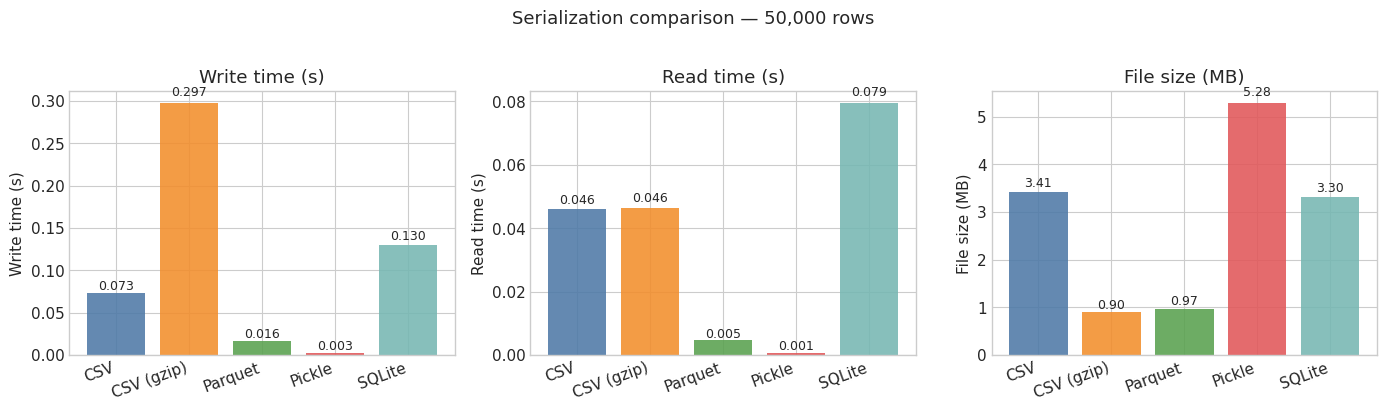

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
palette = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759', '#76b7b2']

for ax, (col, label, color_key) in zip(
    axes,
    [('write_s', 'Write time (s)', 0), ('read_s', 'Read time (s)', 1), ('size_mb', 'File size (MB)', 2)],
):
    ax.bar(results.index, results[col], color=palette, alpha=0.88)
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticklabels(results.index, rotation=20, ha='right')
    for bar, val in zip(ax.patches, results[col]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            f'{val:.3f}' if col != 'size_mb' else f'{val:.2f}',
            ha='center', va='bottom', fontsize=9,
        )

plt.suptitle(
    f'Serialization comparison \u2014 {SAMPLE_SIZE_DETAILS:,} rows',
    y=1.02, fontsize=13,
)
plt.tight_layout()
plt.show()

## The Index Trap in Parquet

When you `.sample()` from a large DataFrame, the result keeps the **original row indices** — a sparse,
non-contiguous subset of 0…9M. Parquet stores the index as a column of large integers that
compress poorly compared to a dense 0…49999 range.

A simple `reset_index(drop=True)` — or passing `index=False` — fixes this.

In [7]:
print('Index type :', type(listings_sample.index).__name__)
print('Index min  :', listings_sample.index.min())
print('Index max  :', listings_sample.index.max())
is_contiguous = list(listings_sample.index) == list(range(len(listings_sample)))
print('Contiguous :', is_contiguous)
print()
print('The index values span the full 0..',
      listings_sample.index.max(),
      'range but only', len(listings_sample),
      'slots are filled — hard to compress.')

Index type : Index
Index min  : 581
Index max  : 9130073
Contiguous : False

The index values span the full 0.. 9130073 range but only 50000 slots are filled — hard to compress.


In [8]:
def benchmark_parquet_with_index(df: pd.DataFrame, tmp: Path, label: str) -> dict:
    """Parquet benchmark that preserves the index (default pandas behaviour)."""
    path = tmp / f'{label}.parquet'
    return {
        'variant': label,
        **measure_write_read(
            lambda p: df.to_parquet(p),   # index=True by default
            pd.read_parquet,
            path,
        ),
    }


with tempfile.TemporaryDirectory() as tmpdir_str:
    tmp = Path(tmpdir_str)
    index_results = pd.DataFrame([
        benchmark_parquet_with_index(
            listings_sample,
            tmp,
            'original index (sparse)',
        ),
        benchmark_parquet_with_index(
            listings_sample.reset_index(drop=True),
            tmp,
            'reset_index() (dense 0..N)',
        ),
        benchmark_parquet_with_index(
            listings_sample.reset_index(drop=True),
            tmp,
            'index=False (no index stored)',
        ),
    ]).set_index('variant')

# override last row: index=False version
with tempfile.TemporaryDirectory() as tmpdir_str:
    tmp = Path(tmpdir_str)
    path = tmp / 'noindex.parquet'
    r = measure_write_read(
        lambda p: listings_sample.to_parquet(p, index=False),
        pd.read_parquet,
        path,
    )
    index_results.loc['index=False (no index stored)', :] = r

index_results

,write_s,read_s,size_mb
variant,,,
original index (sparse),0.011757,0.002000,0.787355
reset_index() (dense 0..N),0.006417,0.001877,0.446679
index=False (no index stored),0.005180,0.001559,0.446266


In [9]:
(
    index_results
    .style
    .background_gradient(cmap='RdYlGn_r', subset=['write_s', 'read_s', 'size_mb'])
    .format({'write_s': '{:.3f} s', 'read_s': '{:.3f} s', 'size_mb': '{:.2f} MB'})
    .set_caption(
        f'Parquet index benchmark \u2014 {SAMPLE_SIZE_LISTINGS:,} rows of ingatlan-listings'
    )
)

,write_s,read_s,size_mb
variant,,,
original index (sparse),0.012 s,0.002 s,0.79 MB
reset_index() (dense 0..N),0.006 s,0.002 s,0.45 MB
index=False (no index stored),0.005 s,0.002 s,0.45 MB


/tmp/ipykernel_2034597/811144586.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=15, ha='right')
/tmp/ipykernel_2034597/811144586.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=15, ha='right')
/tmp/ipykernel_2034597/811144586.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=15, ha='right')


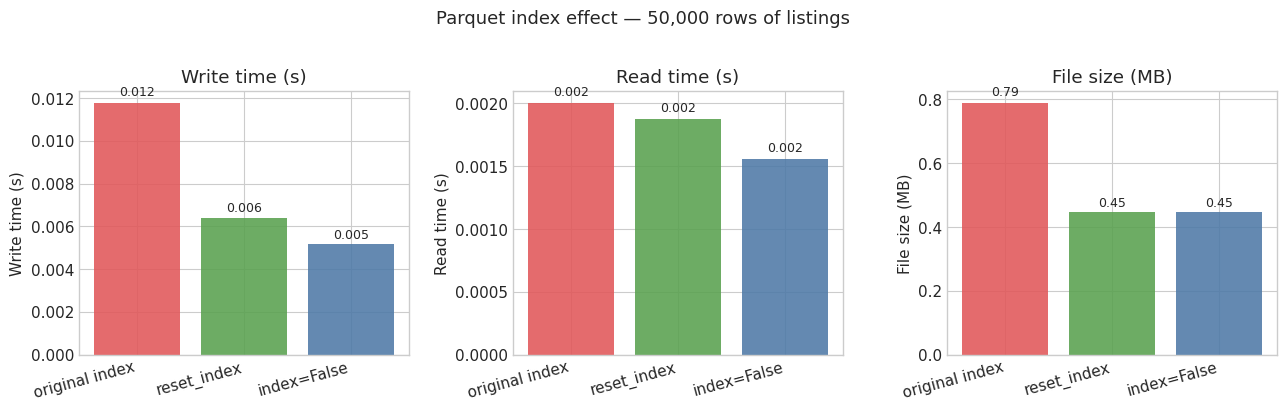

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#e15759', '#59a14f', '#4e79a7']
labels = [v.split('(')[0].strip() for v in index_results.index]

for ax, (col, ylabel) in zip(
    axes,
    [('write_s', 'Write time (s)'), ('read_s', 'Read time (s)'), ('size_mb', 'File size (MB)')],
):
    bars = ax.bar(labels, index_results[col], color=colors, alpha=0.88)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_xticklabels(labels, rotation=15, ha='right')
    for bar, val in zip(bars, index_results[col]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.02,
            f'{val:.3f}' if col != 'size_mb' else f'{val:.2f}',
            ha='center', va='bottom', fontsize=9,
        )

plt.suptitle(
    f'Parquet index effect \u2014 {SAMPLE_SIZE_LISTINGS:,} rows of listings',
    y=1.02, fontsize=13,
)
plt.tight_layout()
plt.show()

### Why does this happen?

Parquet is a **columnar format** that uses dictionary encoding and delta encoding to compress
integer columns. A dense range `[0, 1, 2, …, 49999]` can be stored as metadata
(start + step) and compresses to near zero. A sparse set of random integers drawn from
`[0, 9_130_074]` provides little repetition and no predictable delta — so each value
must be stored explicitly.

**Rule of thumb**: always call `reset_index(drop=True)` — or pass `index=False` —
before writing a sampled or filtered DataFrame to Parquet.